- t-검정으로 두 그룹 평균 비교하기 (mpg 데이터)
- 피어슨 상관분석으로 두 변수 관계 확인하기 (economics)
- 상관행렬 히트맵으로 다변수 상관 시각화 (mtcars)

### 가설 검정
- 기술통계: 데이터 요약
- 추론통계(가설검정): 관측 결과가 우연인지 아닌지 확률로 판단
- 유의확률(p-value) 해석:
    - p < 0.05 → 통계적으로 유의(귀무가설 기각)
    - p >= 0.05 → 통계적으로 유의하지 않음(귀무가설 채택)

In [11]:
import pandas as pd
mpg = pd.read_csv('mpg.csv')

mpg.query('category in ["compact", "suv"]') \
    .groupby('category', as_index=False) \
    .agg(n  = ('category', 'count'),
         mean = ('cty', 'mean')) 

,category,n,mean
0,compact,47,20.12766
1,suv,62,13.50000


In [12]:
compact = mpg.query('category == "compact"')['cty']
suv = mpg.query('category == "suv"')['cty']

### t-검정
- 사용 함수: scipy.stats.ttest_ind
- equal_var=True/False: 두 집단 분산 동일 가정 여부
- 절차 요약:
    1. 데이터 불러오기(mpg)
    2. 그룹별 필터링(예: category == 'compact' vs 'suv')
    3. ttest_ind(그룹1, 그룹2, equal_var=...)
    4. t값과 p값으로 해석

In [13]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
# t-test
from scipy import stats
stats.ttest_ind(compact, suv, equal_var=True)

TtestResult(statistic=11.917282584324107, pvalue=2.3909550904711286e-21, df=107.0)

In [16]:
mpg.query('fl in ["r", "p"]') \
    .groupby('fl', as_index=False) \
    .agg(n  = ('fl', 'count'),
         mean = ('cty', 'mean')) 

,fl,n,mean
0,p,52,17.365385
1,r,168,16.738095


In [17]:
regular = mpg.query('fl == "r"')['cty']
premium = mpg.query('fl == "p"')['cty']

In [18]:
stats.ttest_ind(regular, premium, equal_var=True)

TtestResult(statistic=-1.066182514588919, pvalue=0.28752051088667024, df=218.0)

### 상관분석
- 사용 함수: scipy.stats.pearsonr (r, p-value 반환)
- 주의: 결측치 및 비수치 값 제거 필요(두 변수 모두 존재하는 행만 사용)

In [19]:
economics = pd.read_csv('economics.csv')

economics[['unemploy', 'pce']].corr()

,unemploy,pce
unemploy,1.000000,0.614518
pce,0.614518,1.000000


In [20]:
stats.pearsonr(economics['unemploy'], economics['pce'])

PearsonRResult(statistic=0.6145176141932083, pvalue=6.773527303289381e-61)

In [22]:
import pandas as pd
mtcars = pd.read_csv('mtcars.csv')

In [24]:
car_cor = mtcars.corr()
car_cor = round(car_cor, 2)
car_cor

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.00,-0.85,-0.85,-0.78,0.68,-0.87,0.42,0.66,0.60,0.48,-0.55
cyl,-0.85,1.00,0.90,0.83,-0.70,0.78,-0.59,-0.81,-0.52,-0.49,0.53
disp,-0.85,0.90,1.00,0.79,-0.71,0.89,-0.43,-0.71,-0.59,-0.56,0.39
hp,-0.78,0.83,0.79,1.00,-0.45,0.66,-0.71,-0.72,-0.24,-0.13,0.75
drat,0.68,-0.70,-0.71,-0.45,1.00,-0.71,0.09,0.44,0.71,0.70,-0.09
wt,-0.87,0.78,0.89,0.66,-0.71,1.00,-0.17,-0.55,-0.69,-0.58,0.43
qsec,0.42,-0.59,-0.43,-0.71,0.09,-0.17,1.00,0.74,-0.23,-0.21,-0.66
vs,0.66,-0.81,-0.71,-0.72,0.44,-0.55,0.74,1.00,0.17,0.21,-0.57
am,0.60,-0.52,-0.59,-0.24,0.71,-0.69,-0.23,0.17,1.00,0.79,0.06
gear,0.48,-0.49,-0.56,-0.13,0.70,-0.58,-0.21,0.21,0.79,1.00,0.27


In [25]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi' :120,
                     'figure.figsize' :(7.5, 5.5)})

<Axes: >

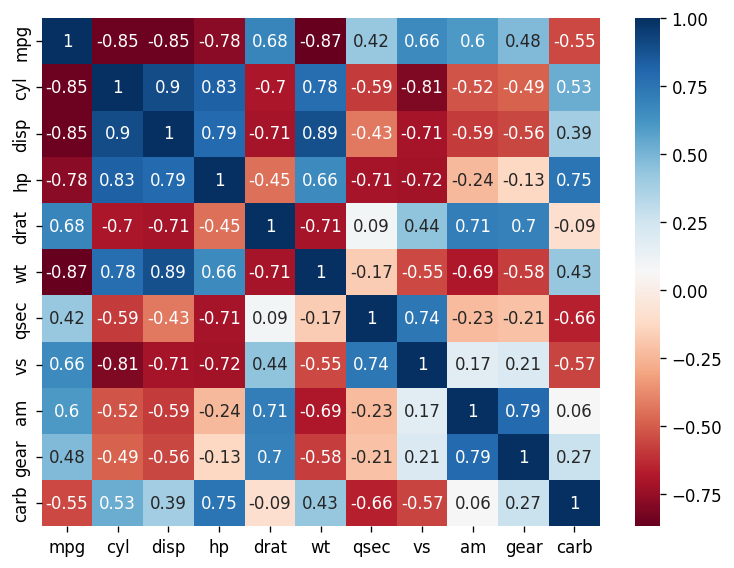

In [26]:
import seaborn as sns
sns.heatmap(car_cor,
            annot = True,
            cmap = 'RdBu')

In [27]:
import numpy as np
mask = np.zeros_like(car_cor)
mask

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [28]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

<Axes: >

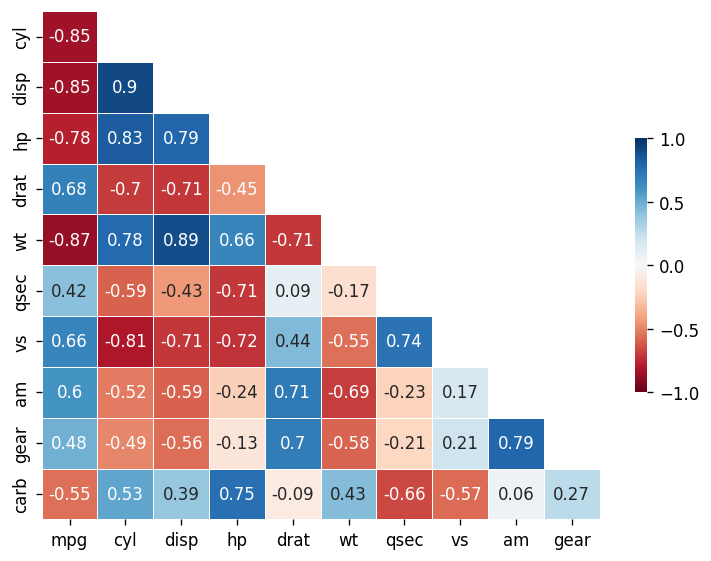

In [30]:
mask_new = mask[1:, :-1]
cor_new = car_cor.iloc[1:, :-1]

sns.heatmap(data=cor_new,
            annot=True,
            cmap='RdBu',
            mask=mask_new,
            linewidths= .5,
            vmax = 1,
            vmin=-1,
            cbar_kws={"shrink": .5})